In [12]:
%load_ext autoreload
%autoreload 2

import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import gsw
# import regionate
import cartopy.crs as ccrs
# import CM4Xutils #needed to run pip install nc-time-axis
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import cartopy.feature as cfeature
import warnings
# from numpy import RankWarning
import cmocean as cm
warnings.filterwarnings('ignore')
import xesmf as xe
from meridional_streamfunction import * 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=8)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter3/bin/python -m distributed.cli.dask_worker tcp://172.16.3.64:42101 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/41990/status,
Dashboard: /proxy/41990/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.64:42101,Workers: 0
Dashboard: /proxy/41990/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [14]:
import xarray as xr

def get_isopycnal_latitude_average(ds, lats, grid=None):
    """
    Calculates the thickness-weighted boundary average of variables across 
    specified latitudes directly on isopycnal coordinates, preserving the 
    time dimension.
    """
    # ====================================================
    # 0. Setup and Variable Extraction
    # ====================================================
    if grid is None:
        grid = CM4Xutils.ds_to_grid(ds, Zprefix="sigma2")
        
    ds_list = []
    
    # Load 2D metrics
    wet = ds["wet"].fillna(0.0)
    area = ds["areacello"].fillna(0.0)
    
    # Load 3D thickness (will include time dimension if present in ds)
    thkcello = ds["thkcello"].fillna(0.0)
    
    # ====================================================
    # 1. Precompute masks and weights for all latitudes
    # ====================================================
    lat_metrics = {}
    
    for l in lats:
        # Calculate convergence across a latitude mask 
        mask_south_yq = ds["geolat_v"] <= l
        boundary_mask_yh = grid.diff(mask_south_yq.astype(float), axis="Y", boundary="fill") < 0 
        
        # Valid ocean boundary points
        valid_bnd = boundary_mask_yh & (wet > 0.0)

        # Calculate 3D cross-sectional area (area * dz) for the weights
        # If thkcello has a time dimension, layer_area will naturally inherit it
        layer_area = (area * thkcello).where(valid_bnd)
        
        # Sum horizontally to get the total cross-sectional area of each isopycnal layer
        tot_layer_area = layer_area.sum(dim=["xh", "yh"], skipna=True)
        
        lat_metrics[l] = {
            "layer_area": layer_area,
            "tot_layer_area": tot_layer_area
        }

    # ====================================================
    # 2. Loop through variables and calculate averages
    # ====================================================
    vars_on_yh = [var for var in ds.data_vars if var != "thkcello"]
    
    for var in vars_on_yh: 
        ds_var_list = []
        ds_var = ds[var]

        for l in lats:
            metrics = lat_metrics[l]
            
            # Multiply variable by layer cross-sectional area and sum horizontally
            # Xarray handles the alignment of the time dimension automatically here
            var_integrated = (ds_var * metrics["layer_area"]).sum(dim=["xh", "yh"], skipna=True)
            
            # Divide by total layer area to get the thickness-weighted average
            term_var_sigma = var_integrated / metrics["tot_layer_area"].where(metrics["tot_layer_area"] > 0)
            
            # Add latitude coordinate for bookkeeping
            term_var_sigma = term_var_sigma.expand_dims({"lat": [l]})
            ds_var_list.append(term_var_sigma)
            
        ds_list.append(xr.concat(ds_var_list, dim="lat").rename(var))

    return xr.merge(ds_list)

In [15]:
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/tracers_sigma2_1p5/" + x
datafiles = glob.glob(datadir("CM4Xp125*"))[20:]
datafiles = sorted(datafiles)

In [16]:
native_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/transient_tracers_z"
files = ["CM4Xp125_piControl_transient_tracers_z.zarr", "CM4Xp125_historical_transient_tracers_z.zarr", "CM4Xp125_ssp585_transient_tracers_z.zarr"]
full_depth_files = [native_path + "/" + a for a in files]

files = ["CM4Xp125_piControl_transient_tracers_surface.zarr", 
         "CM4Xp125_historical_transient_tracers_surface.zarr", 
         "CM4Xp125_ssp585_transient_tracers_surface.zarr"]
surface_files = [native_path + "/" + a for a in files]

In [32]:
def preprocess(ds):
    if ("year_ctrl" in ds.coords) or ("time_ctrl" in ds.coords):
        # if "time_ctrl" in ds.coords:
        #     ds = ds.reset_coords("year_ctrl", drop=True)
        # else:
        #     ds = ds.reset_coords("time_ctrl", drop=True)
        ds = ds.expand_dims(expt=["control"])
        ds.coords["year"] = ds.coords["year"]
        ds = ds.drop_vars(["year_ctrl"])
    else: 
        ds = ds.expand_dims(expt=["forced"])        
    return ds
ds_ctrl= xr.open_mfdataset(full_depth_files[0], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")
ds_forced = xr.open_mfdataset(full_depth_files[1:], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")

ds= xr.concat([ds_ctrl, ds_forced], dim = "expt")
ds.coords["z_i"] = np.array([0.000e+00, 5.000e+00, 1.500e+01, 2.500e+01, 4.000e+01, 6.250e+01,
       8.750e+01, 1.125e+02, 1.375e+02, 1.750e+02, 2.250e+02, 2.750e+02,
       3.500e+02, 4.500e+02, 5.500e+02, 6.500e+02, 7.500e+02, 8.500e+02,
       9.500e+02, 1.050e+03, 1.150e+03, 1.250e+03, 1.350e+03, 1.450e+03,
       1.625e+03, 1.875e+03, 2.250e+03, 2.750e+03, 3.250e+03, 3.750e+03,
       4.250e+03, 4.750e+03, 5.250e+03, 5.750e+03, 6.250e+03, 6.750e+03])

ds["depth"] = approximate_z_bottom_up(ds, dim="z")
ds.coords["depth_i"] = -ds.coords["z_i"].values[::-1]
ds.coords["depth_l"] = -ds.coords["z_l"].values[::-1]

In [33]:
grid = CM4Xutils.ds_to_grid(ds, Zprefix = "z_")
ds_on_z = CM4Xutils.remap_vertical_coord("depth", ds.chunk({"z_l": -1}), grid)


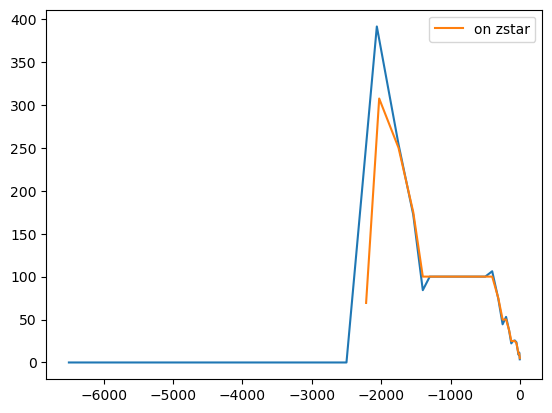

In [34]:

plt.plot(ds_on_z.depth_l, ds_on_z["thkcello"].isel(year = 0, expt = 0, yh = 200, xh = 200))
plt.plot(ds["depth"].isel(year = 0, expt = 0, yh = 200, xh = 200), ds["thkcello"].isel(year = 0, expt = 0, yh = 200, xh = 200), label = "on zstar")
plt.legend()

In [37]:
import cmip_basins.cmip6 as cmip6_basins
from cmip_basins.basins import generate_basin_codes
codes = generate_basin_codes(ds_on_z, lon="geolon", lat="geolat", persian=True, style="cmip6")

so_ind_pac_mask = codes.isin([1, 3, 5, 10, 11])
so_ind_pac_mask = so_ind_pac_mask.where(so_ind_pac_mask > 0.0)

grid = CM4Xutils.ds_to_grid(ds, Zprefix="sigma2")

c_mask = so_ind_pac_mask.where(ds.wet > 0.0)

ds_ind_pac = 1 * ds_on_z 
ds_ind_pac["thkcello"] = ds_ind_pac["thkcello"].where(c_mask > 0.0)
ds_ind_pac["wet"] = ds_ind_pac["wet"].where(c_mask > 0.0)
ds_ind_pac = ds_ind_pac.where(ds_ind_pac["wet"] > 0.0)

lats = np.arange(-75, 60, 1)
ds_zon_ts_ds = get_isopycnal_latitude_average(ds_ind_pac, lats).compute()

In [ ]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
savename = savedir + f"IndoPac_Tracer_Avg_on_sigma2.nc"
ds_zon_ts_ds.to_zarr(savename, compute = True)